In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Pandas版本: {pd.__version__}")
print(f"Numpy版本: {np.__version__}")


Pandas版本: 2.3.3
Numpy版本: 2.0.2


In [10]:
# set random seed
np.random.seed(45)

# set time axis
time = np.arange(0,300)

speed = np.zeros(300)

# 0 - 60s accelerating to 80
speed[0:60] = np.linspace(0, 80, 60) + np.random.normal(0, 1, 60)

# 60 - 120s speed around 80
speed[60:120] = 80 + np.random.normal(0, 2, 60)

# 120 - 180s red light
speed[120:180] = np.linspace(80, 0, 60) + np.random.normal(0, 1, 60)

# 180 - 240s reaccelerates to 60
speed[180:240] = np.linspace(0, 60, 60) + np.random.normal(0, 1, 60)

# 240 - 300s around 60
speed[240:300] = 60 + np.random.normal(0, 1, 60)

speed = np.maximum(speed, 0)

print(f"Generate {len(time)}s driving process.")
print(f"Max speed is {speed.max():.1f}.")
print(f"Average speed is {speed.mean():.1f}.")


Generate 300s driving process.
Max speed is 84.9.
Average speed is 50.0.


In [14]:
# Calculate acceleration (rate of change of speed)
acceleration = np.gradient(speed)

# Find hard acceleration and hard braking
hard_acceleration = acceleration[acceleration > 3]  # acceleration > 3 km/h/s
hard_braking = acceleration[acceleration < -3]      # deceleration < -3 km/h/s

print(f"Number of hard accelerations: {len(hard_acceleration)}")
print(f"Number of hard braking events: {len(hard_braking)}")

# Calculate driving aggressiveness score
aggressive_score = (len(hard_acceleration) + len(hard_braking)) / len(time) * 100
print(f"Driving aggressiveness score: {aggressive_score:.2f}%")
print(f"(Higher score indicates more aggressive driving)")

Number of hard accelerations: 2
Number of hard braking events: 1
Driving aggressiveness score: 1.00%
(Higher score indicates more aggressive driving)


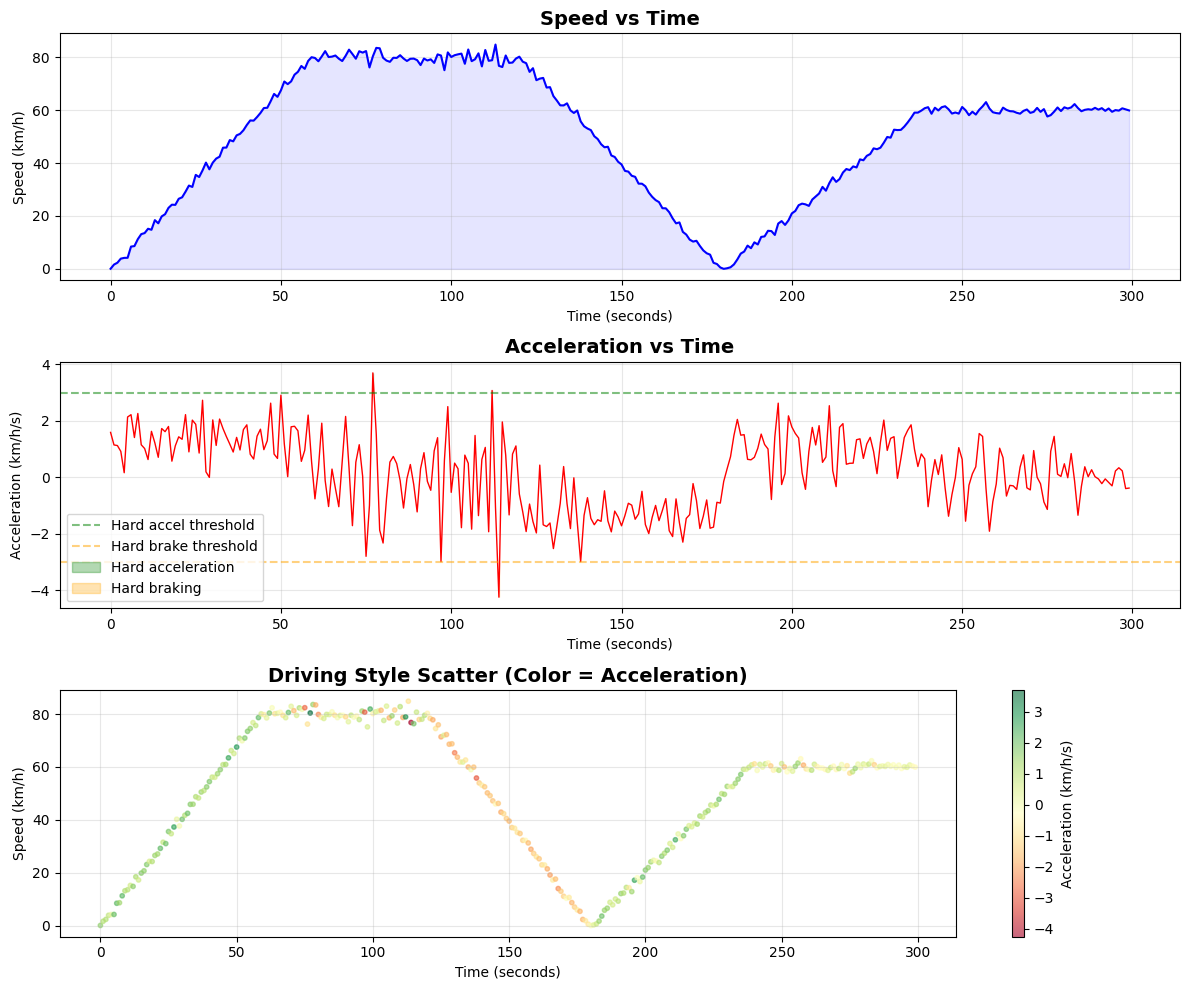

🎉 Congratulations! You've just completed your first driving data analysis!
These charts show your simulated driving session:
- Blue curve: Speed changes
- Red curve: Acceleration changes
- Green/Orange areas: Hard acceleration/braking locations


In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Subplot 1: Speed vs Time
ax1.plot(time, speed, color='blue', linewidth=1.5)
ax1.set_title('Speed vs Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Speed (km/h)')
ax1.grid(True, alpha=0.3)
ax1.fill_between(time, 0, speed, alpha=0.1, color='blue')

# Subplot 2: Acceleration vs Time
ax2.plot(time, acceleration, color='red', linewidth=1)
ax2.axhline(y=3, color='green', linestyle='--', alpha=0.5, label='Hard accel threshold')
ax2.axhline(y=-3, color='orange', linestyle='--', alpha=0.5, label='Hard brake threshold')
ax2.fill_between(time, 3, acceleration, where=(acceleration>3), 
                  color='green', alpha=0.3, label='Hard acceleration')
ax2.fill_between(time, -3, acceleration, where=(acceleration<-3), 
                  color='orange', alpha=0.3, label='Hard braking')
ax2.set_title('Acceleration vs Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Acceleration (km/h/s)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Scatter plot with color representing acceleration
sc = ax3.scatter(time, speed, c=acceleration, cmap='RdYlGn', s=10, alpha=0.6)
ax3.set_title('Driving Style Scatter (Color = Acceleration)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Speed (km/h)')
plt.colorbar(sc, ax=ax3, label='Acceleration (km/h/s)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎉 Congratulations! You've just completed your first driving data analysis!")
print("These charts show your simulated driving session:")
print("- Blue curve: Speed changes")
print("- Red curve: Acceleration changes")
print("- Green/Orange areas: Hard acceleration/braking locations")